In [11]:
import math
import matplotlib.pyplot as plt
import numpy as np

# Probability Distributions

Let $\Omega$ be a sample space. A $\textbf{random variable}$ is a function from $\Omega$ into the real numbers. The value of a random variable $X$ at sample point $\omega$ is $X(\omega)$.

The $\textbf{probability distribution}$ of a random variable $X$ is the collection of probabilities $P(X \in B)$ for sets $B$ of real numbers. The probability mass function of a discrete random variabble $X$ is the function $p$ defined by $p(k) = P(X=k)$ for possible values $k$ of $X$.

We also define the $\textbf{expectation}$, or the $\textbf{mean}$, of a random variable $X$: $\mu \equiv E[X] = \sum\limits_{k}kP(X=k)$, where the sum ranges over all possible values $k$ of $X$. Moreover, we define the $\textbf{variance}$ of a random variable $X$: $Var(X) = E[(X - E[X])^2)]$. The variance is a measure of how much the random variable fluctuates around its expectation. The $\textbf{standard deviation}$ is the square root of the variance.

We consider common probability distributions.

## Bernoulli Distribution

Let $0 \leq p \leq 1$. A random variable $X$ has the Bernoulli distribution with success probability $p$ if $X$ is $\{0,1\}$-valued and satisfies $P(X=0)=1-p$ and $P(X=1)=p$.

A sequence of $n$ independent repititions of a trial with successs probability $p$ gives rise to a sequence of $n$ independent Bernoulli random variables with success probability $p$, which probabilities can be multiplied together.

In [12]:
# define the binomial probability function
def bernoulli_probability(n, p):
    if p < 0 or p > 1:
        raise ValueError("The success probability must be between zero and one inclusive.")
    if n != 0 and n != 1:
        raise ValueError("The random variable must have a value of zero or one.")
    if n == 0:
        return 1 - p
    if n == 1:
        return p

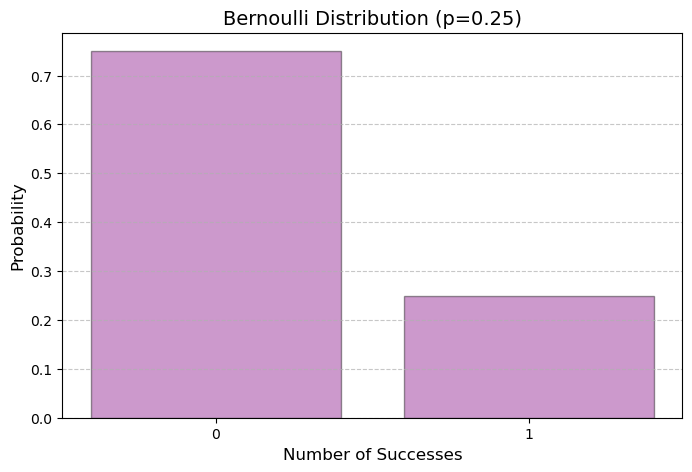

In [13]:
p = 0.25

x = np.arange(0, 1 + 1)
probabilities = [bernoulli_probability(successes, p) for successes in x]

plt.figure(figsize=(8, 5))
plt.bar(x, probabilities, color='purple', edgecolor='black', alpha=0.4)

plt.title(f'Bernoulli Distribution (p={p})', fontsize=14)
plt.xlabel('Number of Successes', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Expectation and Variance of Bernoulli

$$
\begin{split}
\textcolor{red}{E[X]} = \sum\limits_{k = 0}^{1} kP(X=k) &= 0 \cdot (1-p) + 1 \cdot p \\
    &= \boxed{\textcolor{red}{p}}
\end{split}
$$

$$
\begin{split}
\textcolor{red}{Var(X)} = \sum\limits_{k = 0}^{1} (k - E[X])^2 \cdot P(X=k) &=  (0 - p)^2 \cdot (1-p) + (1 - p)^2 \cdot p \\
    &= p^2 - p^3 + (1 - 2p + p^2) \cdot p \\
    &= p^2 - p^3 + p - 2p^2 + p^3 \cdot p \\
    &= p - p^2 \cdot p \\
    &= \boxed{\textcolor{red}{p\cdot(1-p)}}
\end{split}
$$

## Binomial Distribution

The binomial distribution arises from counting successes. If there are $n$ trials with $k$ successes, from cominatorics there are $\binom{n}{k}$ ways to obtain such successes. 

Let $0 \leq p \leq 1$. A random variable $X$ has the binomial distribution with parameters $n$ and $p$ if the possible values of $X$ are $\{0, 1, ..., n\}$, and it has the probabilities: $$P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$$

In [14]:
def binomial_probability(n, k, p):
    if p < 0 or p > 1:
        raise ValueError("The success probability must be between zero and one inclusive.")
    return math.comb(n, k)*(p**k)*((1-p)**(n-k))

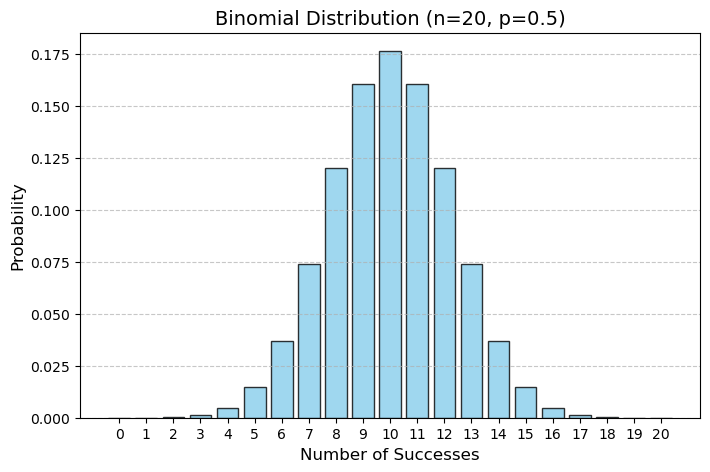

In [15]:
n = 20
p = 0.5

x = np.arange(0, n + 1)
probabilities = [binomial_probability(n, successes, p) for successes in x]

plt.figure(figsize=(8, 5))
plt.bar(x, probabilities, color='skyblue', edgecolor='black', alpha=0.8)

plt.title(f'Binomial Distribution (n={n}, p={p})', fontsize=14)
plt.xlabel('Number of Successes', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Expectation and Variance of Binomial

$$
\begin{split}
\textcolor{red}{E[X]} = \sum\limits_{k = 0}^{n} kP(X=k) &= \sum\limits_{k = 0}^{n} k \binom{n}{k} p^k (1-p)^{n-k} \\
    &= \sum\limits_{k = 0}^{n} k \frac{n!}{k!(n-k)!} p^k (1-p)^{n-k} \\
    &= \sum\limits_{k = 1}^{n} \frac{n \cdot (n-1)!}{(k-1)!(n-k)!} p \cdot p^{k-1} (1-p)^{n-k} \quad \text{(Note: $k=0$ term is 0. Reduce $k$ and factor out $np$.)} \\
    &= np \sum\limits_{j = 0}^{n-1} \frac{(n-1)!}{j!(n-1-j)!} p^j (1-p)^{n-1-j} \quad \text{(Note: Define $j = k-1$.)} \\
    &= np \sum\limits_{j = 0}^{n-1} \binom{n-1}{j} p^j (1-p)^{(n-1)-j} \quad \text{(Note: Summing the probabilities of a binomial across values $k$ equals $1$.)} \\
    &= \boxed{\textcolor{red}{np}}
\end{split}
$$

By similar means, we can compute $E[X^2] = n(n-1)p^2 + np$. 

$$
\begin{split}
E[X^2] = \sum\limits_{k = 0}^{n} k^2P(X=k) &= \sum\limits_{k = 0}^{n} k^2 \binom{n}{k} p^k (1-p)^{n-k} \\
    &= \sum\limits_{k = 0}^{n} k^2 \frac{n!}{k!(n-k)!} p^k (1-p)^{n-k} \\
    &= \sum\limits_{k = 1}^{n} k \frac{n!}{(k-1)!(n-k)!} p^k (1-p)^{n-k} \quad \text{(Note: $k=0$ term is 0. Reduce $k$.)} \\
    &= \sum\limits_{k = 2}^{n} (k-1) \frac{n!}{(k-1)!(n-k)!} p^k (1-p)^{n-k} + \sum\limits_{k = 1}^{n} \frac{n!}{(k-1)!(n-k)!} p^k (1-p)^{n-k} \quad \text{(Note: Define $k = k-1+1$.)} \\
    &= \sum\limits_{k = 2}^{n} \frac{n!}{(k-2)!(n-k)!} p^k (1-p)^{n-k} + \sum\limits_{k = 1}^{n} \frac{n!}{(k-1)!(n-k)!} p^k (1-p)^{n-k} \quad \text{(Note: Cancel $(k-1)$.)} \\
    &= n(n-1)p^2 + np \quad \text{(Note: For the left sum, factor out $np^2$ and define $j = k-2$. The right sum is the expectation.)}
\end{split}
$$


Since $Var(X) = E[X^2] - (E[X])^2$, we have:

$$
\textcolor{red}{Var(X)} = n(n-1)p^2 + np - n^2p^2 = \boxed{\textcolor{red}{np(1-p)}}
$$

## Geometric Distribution

Let $0 < p \leq 1$. A random variable $X$ has the geometric distribution with success parameter $p$ if the possible values of $X$ are $\{1, 2, 3, ...\}$ and $X$ satisfies $P(X=k) = (1-p)^{k-1}p$ for positive integers $k$. The difference between the Bernoulli distribution and the geometric distribution is allowing a potentially infinite sequence of independent trials needed to see a success.

In [16]:
def geometric_probability(k, p):
    if p < 0 or p > 1:
        raise ValueError("The success probability must be between zero and one inclusive.")
    return p*((1-p)**(k-1))

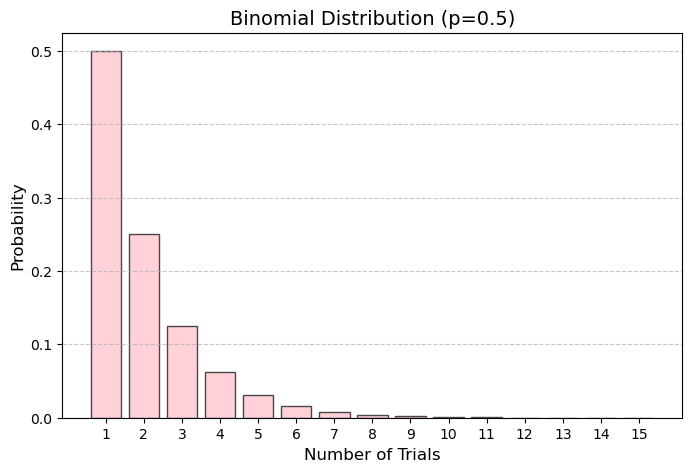

In [17]:
# choose a finite number of trials, n, to graph
n = 15
p = 0.5

x = np.arange(1, n + 1)
probabilities = [geometric_probability(k, p) for k in x]

plt.figure(figsize=(8, 5))
plt.bar(x, probabilities, color='pink', edgecolor='black', alpha=0.7)

plt.title(f'Binomial Distribution (p={p})', fontsize=14)
plt.xlabel('Number of Trials', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Expectation and Variance of Geometric

$$
\begin{split}
\textcolor{red}{E[X]} = \sum\limits_{k = 1}^{\infty} kP(X=k) &= \sum\limits_{k = 1}^{\infty} k(1-p)^{k-1}p \\
    &= p \sum\limits_{k = 1}^{\infty} \frac{d}{dq} \left[ q^k \right] \quad \text{(Note: Define $q \equiv 1-p$.)} \\
    &= p \frac{d}{dq} \left[ \sum\limits_{k = 0}^{\infty} q^k \right] \quad \text{(Note: $k=0$ term is $0$.)} \\
    &= p \frac{d}{dq} \left[ \frac{1}{1-q} \right] \\
    &= p \frac{1}{(1-q)^2} \\
    &= \boxed{\textcolor{red}{\frac{1}{p}}}
\end{split}
$$

We compute the variance by noting that $E[X^2] = E[X] + E[X(X-1)]$, since the expectation is a linear operator.

$$
\begin{split}
E[X(1-X)] = \sum\limits_{k = 1}^{\infty} k(1-k)P(X=k) &= \sum\limits_{k = 1}^{\infty} k(1-k)(1-p)^{k-1}p \quad \text{(Note: Define $q \equiv 1-p$.)} \\
    &= pq \sum\limits_{k = 0}^{\infty} \frac{d^2}{dq^2} \left[ q^k \right] \quad \text{(Note: $k=0$ term is $0$. factor out a $q$.)} \\
    &= pq \frac{d^2}{dq^2} \left[ \sum\limits_{k = 0}^{\infty} q^k \right] \\
    &= pq \frac{d^2}{dq^2} \left[ \frac{1}{1-q} \right] \\
    &= pq \frac{2}{(1-q)^3} \\
    &= \frac{2(1-p)}{p^2}
\end{split}
$$

Thus, we have the variance:

$$
\textcolor{red}{Var(X)} = E[X^2] - (E[X])^2 = E[X] + E[X(X-1)] - (E[X])^2 = \frac{1}{p} + \frac{2(1-p)}{p^2} - \frac{1}{p^2} = \boxed{\textcolor{red}{\frac{1-p}{p^2}}}
$$

## Hypergeometric Distribution

Suppose there are two groups of items: group A and group B. Let $N = N_A + N_B$ be the total number of items between groups, where $N_A$ is the number of items in group A, and $N_B$ is the number of items in group B. We sample $n$ items without replacement. We define the random variable $X$ to be the number of items sampled from group A. 

Let $0 \leq N_A \leq N$ and $1 \leq n \leq N$ be integers. A random variable $X$ has the hypergeometric distribution with parameters $(N, N_A, n)$ if $X$ takes values in the set $\{0, 1, ..., n\}$ and has probability mass function $$P(X=k) = \frac{\binom{N_A}{k}\binom{N-N_A}{n - k}}{\binom{N}{n}}$$ for $k = 0, 1, ..., n$, where $N-N_A=N_B$.

In [18]:
def hypergeometric_probability(N, N_a, n, k):
    return math.comb(N_a, k) * math.comb(N - N_a, n - k) / math.comb(N, n)

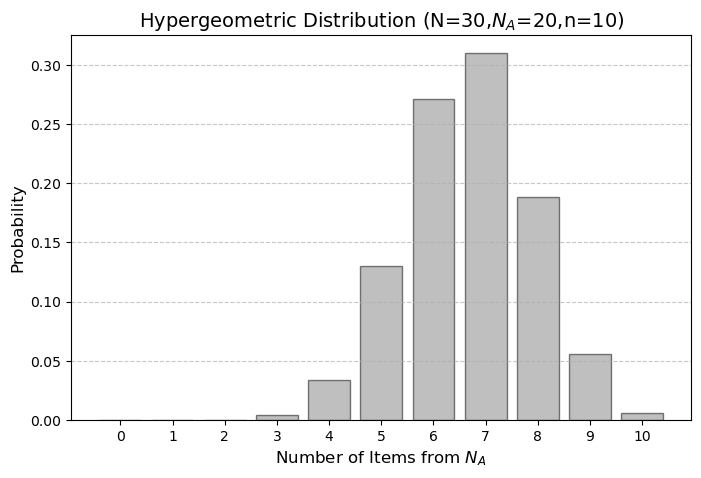

In [19]:
# choose a finite number of trials, n, to graph
N = 30
N_a = 20
n = 10

x = np.arange(0, n + 1)
probabilities = [hypergeometric_probability(N, N_a, n, k) for k in x]

plt.figure(figsize=(8, 5))
plt.bar(x, probabilities, color='grey', edgecolor='black', alpha=0.5)

plt.title(f'Hypergeometric Distribution (N={N},$N_A$={N_a},n={n})', fontsize=14)
plt.xlabel('Number of Items from $N_A$', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Expectation and Variance of Hypergeometric

$$
\begin{split}
\textcolor{red}{E[X]} = \sum\limits_{k = 0}^{n} kP(X=k) &= \sum\limits_{k = 0}^{n} k\frac{\binom{N_A}{k}\binom{N-N_A}{n-k}}{\binom{N}{n}} \\
    &= \sum\limits_{k = 1}^{n} k\frac{\binom{N_A}{k}\binom{N-N_A}{n-k}}{\binom{N}{n}} \quad \text{(Note: $k=0$ term is $0$.)}\\
    &= \sum\limits_{k = 1}^{n} k\frac{\frac{N_A}{k}\binom{N_A-1}{k-1}\binom{N-N_A}{n-k}}{\frac{N}{n}\binom{N-1}{n-1}} \quad \text{(Note: Using binomial identities.)}\\
    &= \frac{N_A}{\frac{N}{n}} \sum\limits_{k = 1}^{n} \frac{\binom{N_A-1}{k-1}\binom{N-N_A}{n-k}}{\binom{N-1}{n-1}} \quad \text{(Note: Using binomial identities.)}\\
    &= \frac{N_A}{\frac{N}{n}} \sum\limits_{j = 0}^{n-1} \frac{\binom{N_A-1}{j}\binom{N-N_A}{n-1-j}}{\binom{N-1}{n-1}} \quad \text{(Note: Define $j=k-1$.)}\\
    &= \frac{N_A}{\frac{N}{n}} \sum\limits_{j = 0}^{y} \frac{\binom{M}{j}\binom{Y-M}{y-j}}{\binom{Y}{y}} \quad \text{Define $M=N_A-1$, $Y=N-1$,$y=n-1$}\\
    &= \boxed{\textcolor{red}{\frac{nN_A}{N}}}
\end{split}
$$

We compute the variance by noting, as with the derivation for the geometric disttribution, that $E[X^2] = E[X] + E[X(X-1)]$, since the expectation is a linear operator.

$$
\begin{split}
E[X(1-X)] = \sum\limits_{k = 1}^{\infty} k(1-k)P(X=k) &= \sum\limits_{k = 0}^{n} k(k-1)\frac{\binom{N_A}{k}\binom{N-N_A}{n-k}}{\binom{N}{n}} \\
    &= \sum\limits_{k = 2}^{n} k(k-1)\frac{\binom{N_A}{k}\binom{N-N_A}{n-k}}{\binom{N}{n}} \quad \text{(Note: $k=0,1$ terms are $0$.)} \\
    &= \frac{N_A(N_A-1) \cdot n(n-1)}{N(N-1)} \sum\limits_{k = 2}^{n} \frac{\binom{N_A-2}{k-2}\binom{N-N_A}{n-k}}{\binom{N-2}{n-2}} \quad \text{(Note: $\frac{x(x-1)}{y(y-1)}\binom{x-2}{y-2} = \binom{x}{y}$, reduce $k(k-1))$.)} \\
    &= \frac{N_A(N_A-1) \cdot n(n-1)}{N(N-1)} \sum\limits_{k = 0}^{m} \frac{\binom{M}{j}\binom{Y - M}{m - j}}{\binom{Y}{m}} \quad \text{(Note: Define $M \equiv N_A - 2$,$m \equiv n - 2$, $Y \equiv N - 2$, and $j \equiv k - 2$.)} \\
    &= \frac{N_A(N_A-1) \cdot n(n-1)}{N(N-1)} \sum\limits_{k = 0}^{m} \frac{\binom{M}{j}\binom{Y - M}{m - j}}{\binom{Y}{m}}
\end{split}
$$

Thus, we have the variance:

$$
\begin{split}
\textcolor{red}{Var(X)} = E[X^2] - (E[X])^2 = E[X] + E[X(X-1)] - (E[X])^2 &= \left[ \frac{nN_A}{N} + \frac{N_A(N_A-1) \cdot n(n-1)}{N(N-1)} \right] - \left( \frac{nN_A}{N} \right)^2\\
    &= \frac{nN_A}{N} \left[ 1 + \frac{N_A(N_A-1) \cdot n(n-1)}{N(N-1)} - \frac{nN_A}{N} \right]\\
    &= \frac{nN_A}{N} \left[ \frac{N(N-1) + N(N_A-1)(n-1) - nN_A(N-1)}{N(N-1)} \right]\\
    &= \frac{nN_A}{N} \left[ \frac{(N^2 - N_AN) - (nN - nN_A)}{N(N-1)} \right]\\
    &= \frac{nN_A}{N} \left[ \frac{(N-n)(N - N_A)}{N(N-1)} \right]\\
    &= \boxed{\textcolor{red}{\frac{nN_A}{N} \left( 1 - \frac{N_A}{N} \right) \left( \frac{N-n}{N-1} \right)}}
\end{split}
$$